In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\babus\Data_Spark\Data_analysis_practice\Data Collection\boston_data.csv")

In [3]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,21.7
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,19.6
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,20.3
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,15.4
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,20.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,9.32909,0.0,18.10,0.0,0.713,6.185,98.7,2.2616,24.0,666.0,20.2,396.90,18.13,14.1
400,51.13580,0.0,18.10,0.0,0.597,5.757,100.0,1.4130,24.0,666.0,20.2,2.60,10.11,15.0
401,0.01501,90.0,1.21,1.0,0.401,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,50.0
402,0.02055,85.0,0.74,0.0,0.410,6.383,35.7,9.1876,2.0,313.0,17.3,396.90,5.77,24.7


In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.00000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.730912,10.509901,11.189901,0.069307,0.556710,6.30145,68.601733,3.799666,9.836634,411.688119,18.444554,355.068243,12.598936,22.312376
std,8.943922,22.053733,6.814909,0.254290,0.117321,0.67583,28.066143,2.109916,8.834741,171.073553,2.150295,94.489572,6.925173,8.837019
min,0.006320,0.000000,0.460000,0.000000,0.392000,3.56100,2.900000,1.169100,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082382,0.000000,5.190000,0.000000,0.453000,5.90275,45.800000,2.087875,4.000000,281.000000,17.375000,374.710000,7.135000,17.100000
50%,0.253715,0.000000,9.795000,0.000000,0.538000,6.23050,76.600000,3.207450,5.000000,330.000000,19.000000,391.065000,11.265000,21.400000
75%,4.053158,12.500000,18.100000,0.000000,0.631000,6.62925,94.150000,5.222125,24.000000,666.000000,20.200000,396.007500,16.910000,25.000000
max,88.976200,95.000000,27.740000,1.000000,0.871000,8.78000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,34.370000,50.000000


In [5]:
status = df.agg(['mean','median','var','std','skew','kurtosis'])
status

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
mean,3.730912,10.509901,11.189901,0.069307,0.556710,6.301450,68.601733,3.799666,9.836634,411.688119,18.444554,355.068243,12.598936,22.312376
median,0.253715,0.000000,9.795000,0.000000,0.538000,6.230500,76.600000,3.207450,5.000000,330.000000,19.000000,391.065000,11.265000,21.400000
var,79.993745,486.367147,46.442989,0.064664,0.013764,0.456747,787.708359,4.451745,78.052650,29266.160553,4.623767,8928.279283,47.958014,78.092899
std,8.943922,22.053733,6.814909,0.254290,0.117321,0.675830,28.066143,2.109916,8.834741,171.073553,2.150295,94.489572,6.925173,8.837019
skew,5.379377,2.323321,0.265428,3.404266,0.753866,0.330078,-0.617982,1.043365,0.933593,0.629535,-0.825967,-2.829631,0.817233,1.068608
kurtosis,38.252363,4.602726,-1.231174,9.636708,-0.083612,2.301356,-0.889310,0.659247,-1.020608,-1.228888,-0.226789,6.744756,0.090950,1.728430


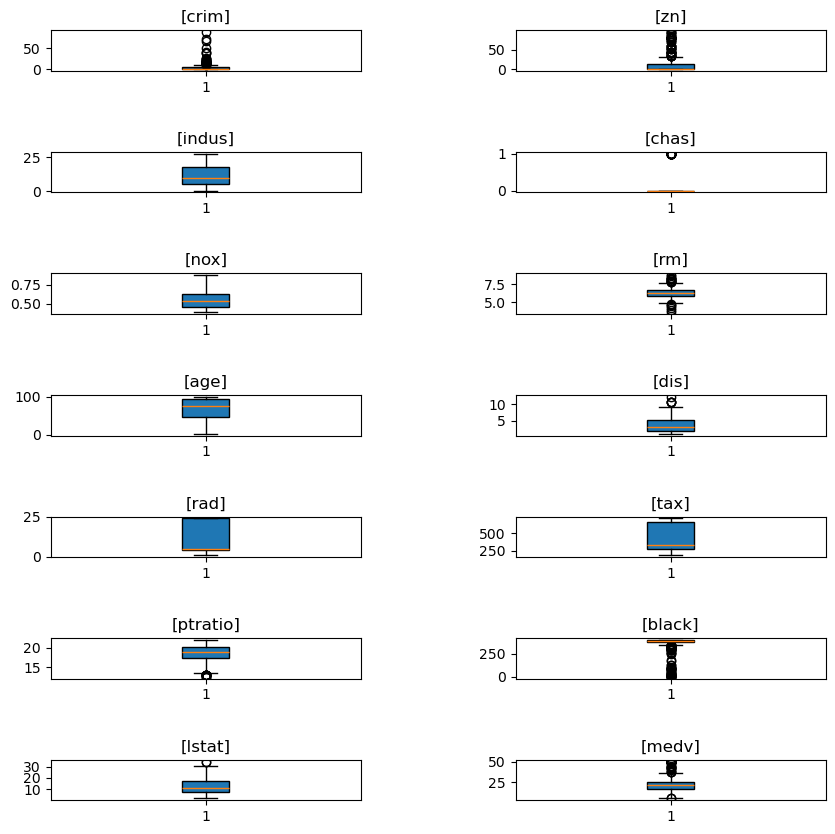

In [6]:
plt.figure(figsize=(10,10))
for i,col in enumerate(df.columns,start=1):
    plt.subplot(7,2,i)
    plt.title(f"[{col}]")
    plt.boxplot(df[col],patch_artist=True)
plt.subplots_adjust(wspace=0.5,hspace=2)
plt.show()

In [7]:
# CRIM
Q1 = df['crim'].quantile(0.25)
Q3 = df['crim'].quantile(0.75)

IQR = Q3 - Q1

LOWER_LIMIT = Q1 - IQR * 1.5
UPPER_LIMIT = Q3 + IQR * 1.5

OUTLIERS = ( df['crim'] < LOWER_LIMIT ) | ( df['crim'] > UPPER_LIMIT )
TRIMMED_CRIM = df['crim'].loc[~OUTLIERS]

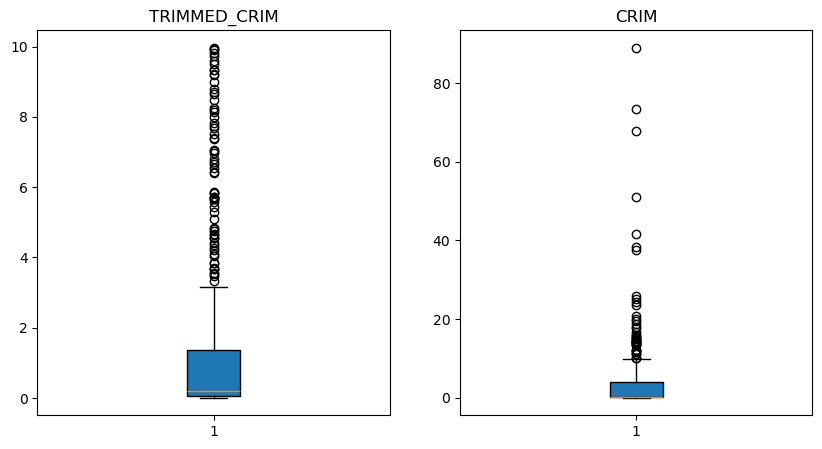

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("TRIMMED_CRIM")
plt.boxplot(TRIMMED_CRIM,patch_artist=True)
plt.subplot(1,2,2)
plt.title("CRIM")
plt.boxplot(df['crim'],patch_artist=True)
plt.show()

In [9]:
# ZN

Q1 = df['zn'].quantile(0.25)
Q3 = df['zn'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['zn'] > Upper_Limit ) | (df['zn'] < Lower_Limit)
Trimmed_Zn = df['zn'].loc[~Outliers]


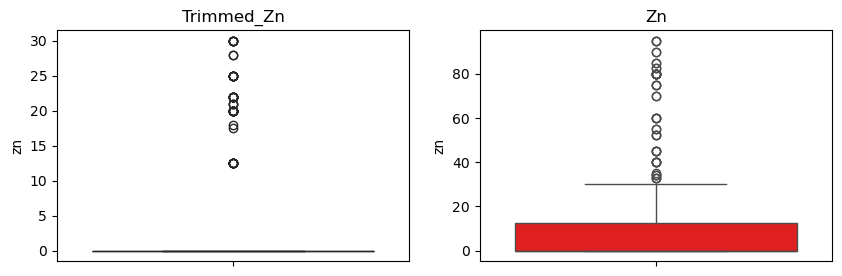

In [10]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_Zn")
sns.boxplot(data = Trimmed_Zn,color='g')

plt.subplot(1,2,2)
plt.title("Zn")
sns.boxplot(df['zn'],color='r')
plt.show()

In [11]:
# chas

Q1 = df['chas'].quantile(0.25)
Q3 = df['chas'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['chas'] < Lower_Limit ) | ( df['chas'] > Upper_Limit )
Trimmed_chas = df['chas'].loc[~Outliers]


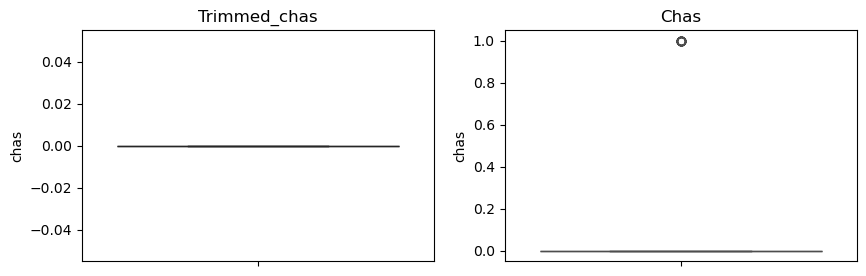

In [12]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_chas")
sns.boxplot(data = Trimmed_chas,color='g')

plt.subplot(1,2,2)
plt.title("Chas")
sns.boxplot(df['chas'],color='r')
plt.show()

In [13]:
# rm
Q1 = df['rm'].quantile(0.25)
Q3 = df['rm'].quantile(0.75)

IQR = Q3 - Q1

Lower_limit  = Q1 - IQR * 1.5
Upper_limit = Q3 + IQR * 1.5

Outliers = (df['rm'] < Lower_limit) | (df['rm'] > Upper_limit)
trimmed_rm = df['rm'].loc[~Outliers]


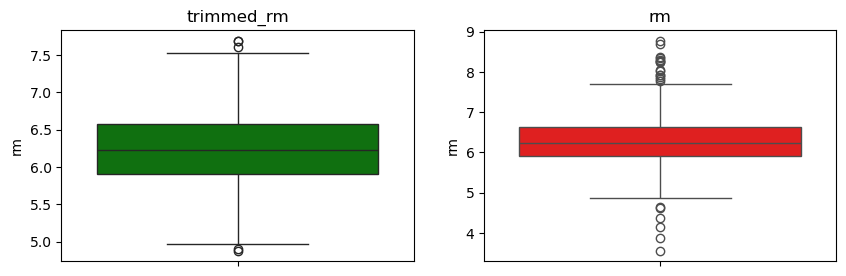

In [14]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("trimmed_rm")
sns.boxplot(data=trimmed_rm,color='g')
plt.subplot(1,2,2)
plt.title("rm")
sns.boxplot(data=df['rm'],color='r')
plt.show()

In [15]:
# dis

Q1 = df['dis'].quantile(0.25)
Q3 = df['dis'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['dis'] < Lower_Limit ) | ( df['dis'] > Upper_Limit )
Trimmed_dis = df['dis'].loc[~Outliers]

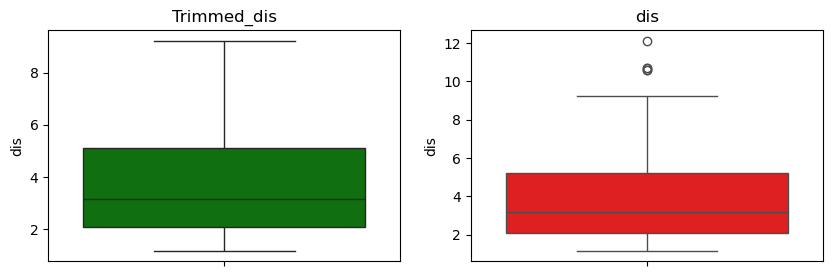

In [16]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_dis")
sns.boxplot(data = Trimmed_dis,color='g')
plt.subplot(1,2,2)
plt.title("dis")
sns.boxplot(df['dis'],color='r')
plt.show()

In [17]:
# ptratio

Q1 = df['ptratio'].quantile(0.25)
Q3 = df['ptratio'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['ptratio'] < Lower_Limit ) | ( df['ptratio'] > Upper_Limit )
Trimmed_ptratio = df['ptratio'].loc[~Outliers]

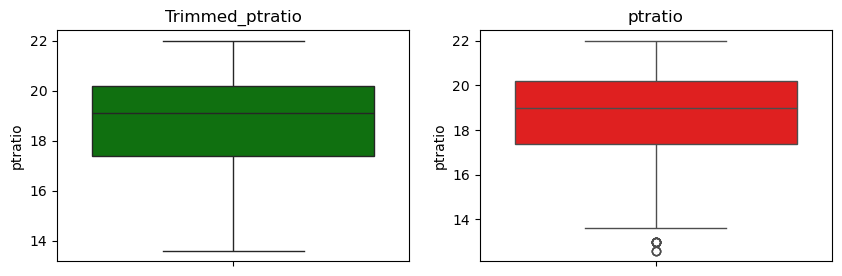

In [18]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_ptratio")
sns.boxplot(data = Trimmed_ptratio,color='g')
plt.subplot(1,2,2)
plt.title("ptratio")
sns.boxplot(df['ptratio'],color='r')
plt.show()

In [19]:
# black

Q1 = df['black'].quantile(0.25)
Q3 = df['black'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['black'] < Lower_Limit ) | ( df['black'] > Upper_Limit )
Trimmed_black = df['black'].loc[~Outliers]

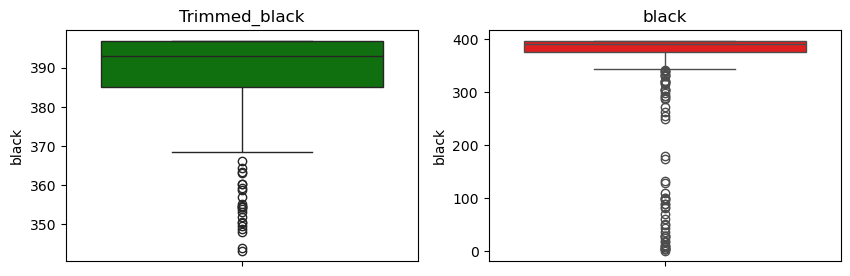

In [20]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_black")
sns.boxplot(data = Trimmed_black,color='g')
plt.subplot(1,2,2)
plt.title("black")
sns.boxplot(df['black'],color='r')
plt.show()

In [21]:
# lstat

Q1 = df['lstat'].quantile(0.25)
Q3 = df['lstat'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['lstat'] < Lower_Limit ) | ( df['lstat'] > Upper_Limit )
Trimmed_lstat = df['lstat'].loc[~Outliers]

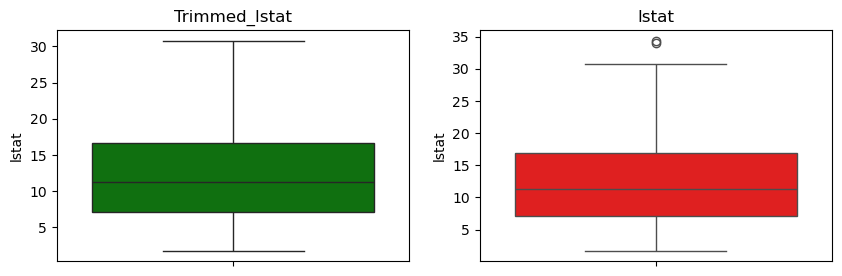

In [22]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_lstat")
sns.boxplot(data = Trimmed_lstat,color='g')
plt.subplot(1,2,2)
plt.title("lstat")
sns.boxplot(df['lstat'],color='r')
plt.show()

In [23]:
# medv

Q1 = df['medv'].quantile(0.25)
Q3 = df['medv'].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - IQR * 1.5
Upper_Limit = Q3 + IQR * 1.5

Outliers = ( df['medv'] < Lower_Limit ) | ( df['medv'] > Upper_Limit )
Trimmed_medv = df['medv'].loc[~Outliers]

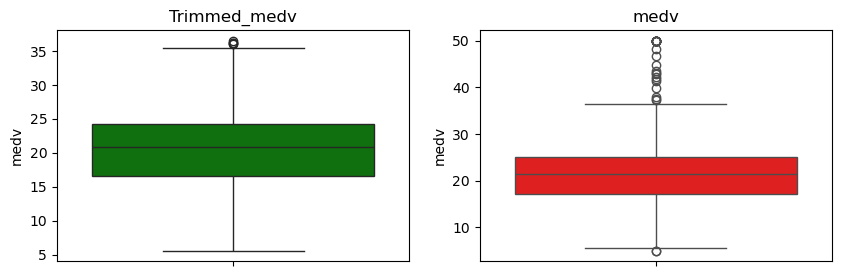

In [24]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Trimmed_medv")
sns.boxplot(data = Trimmed_medv,color='g')

plt.subplot(1,2,2)
plt.title("medv")
sns.boxplot(df['medv'],color='r')

plt.show()

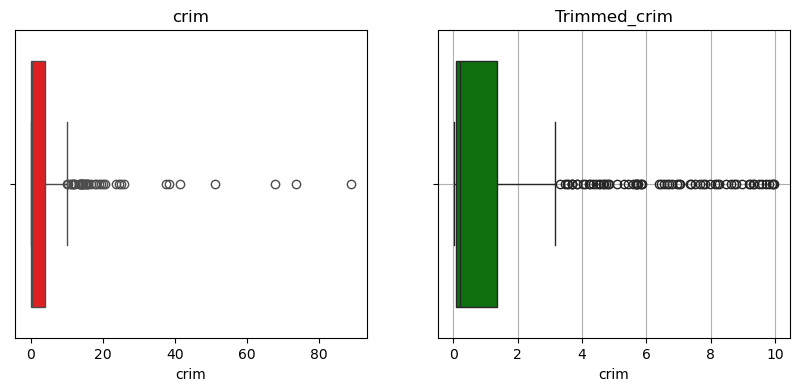

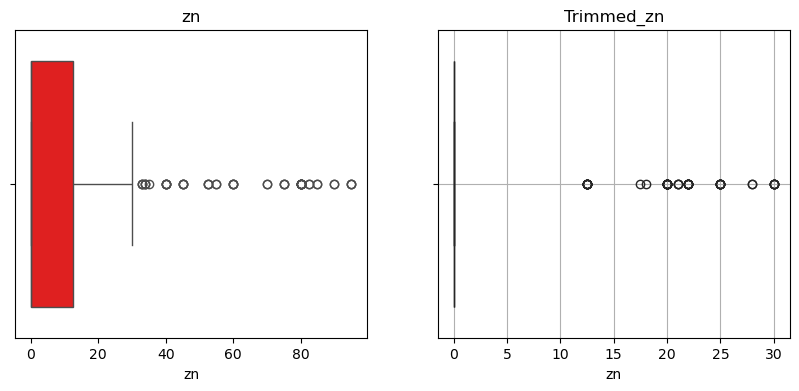

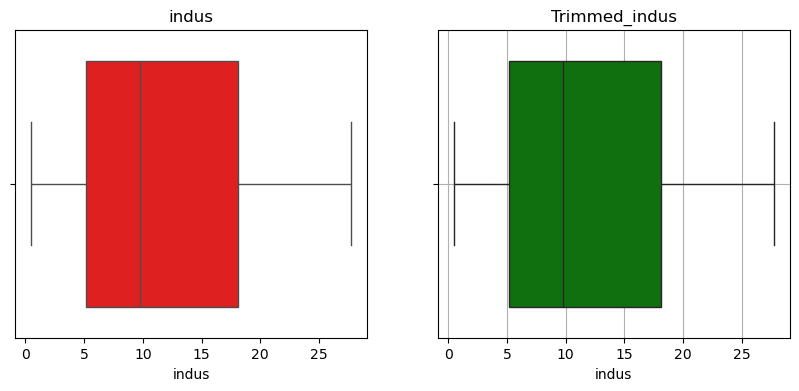

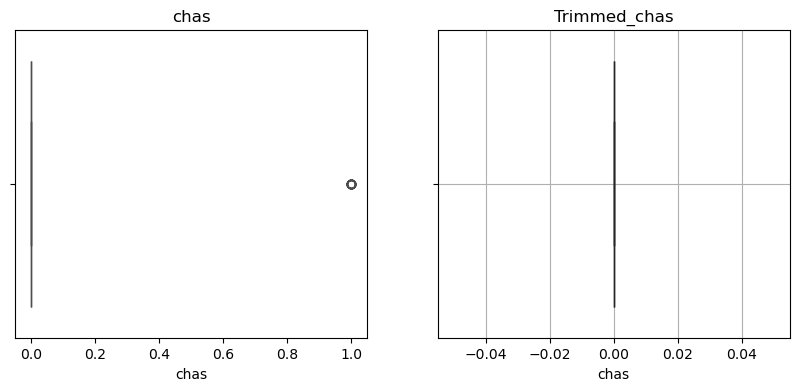

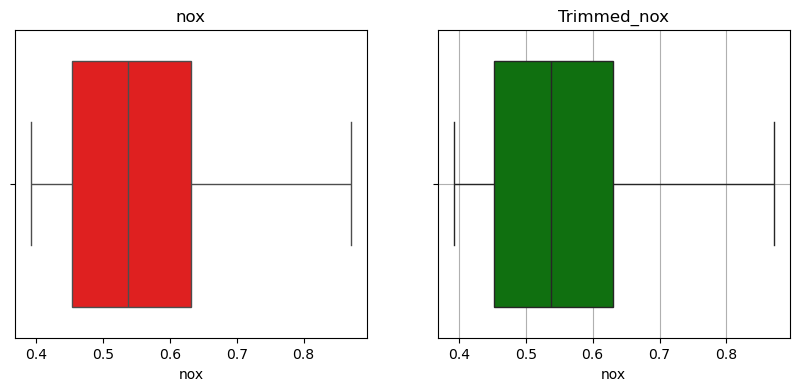

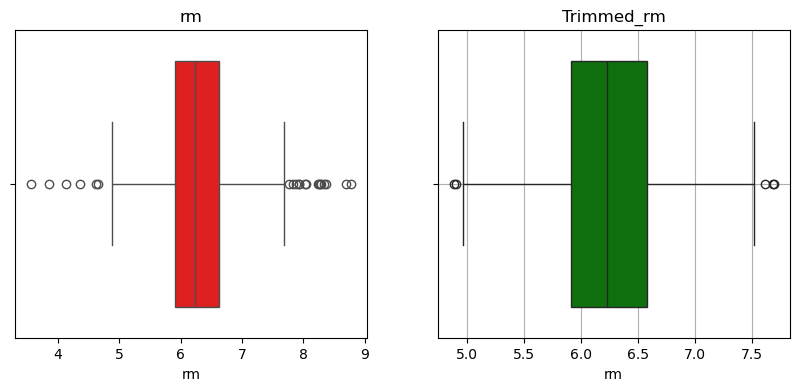

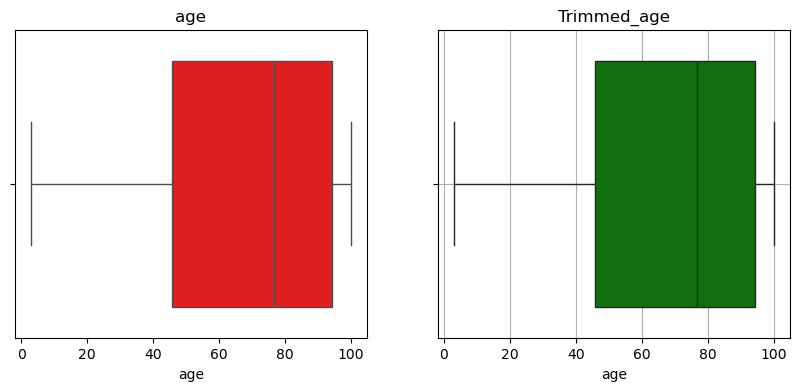

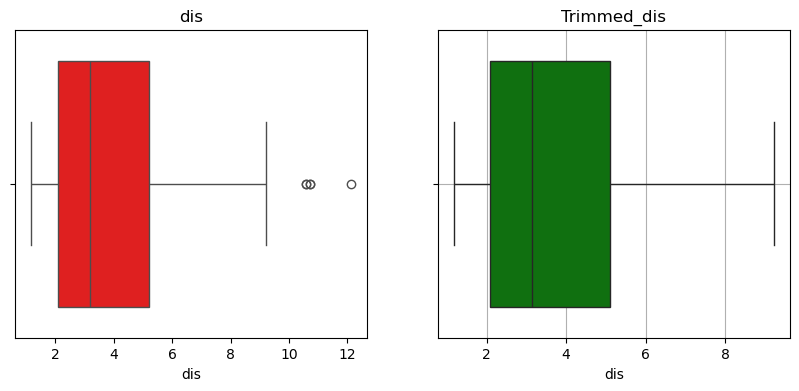

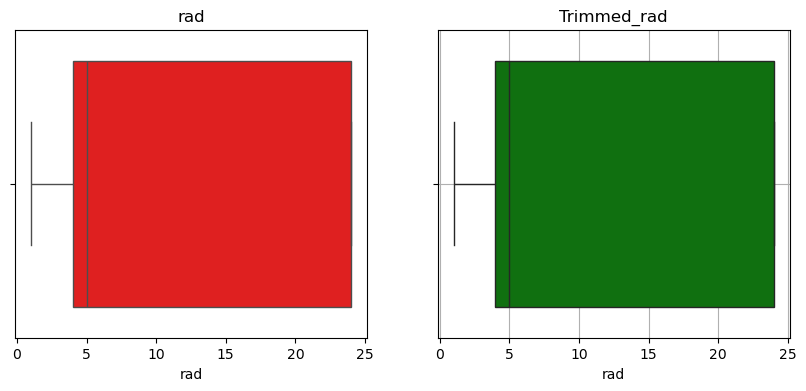

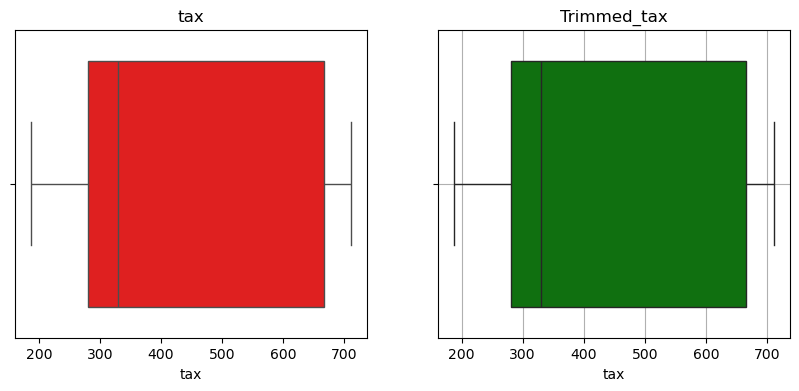

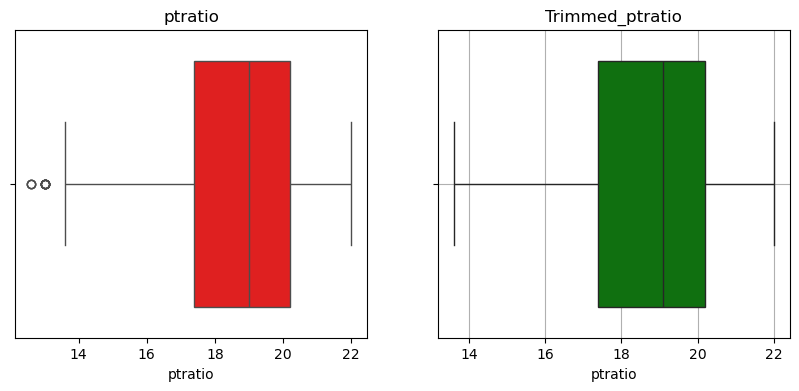

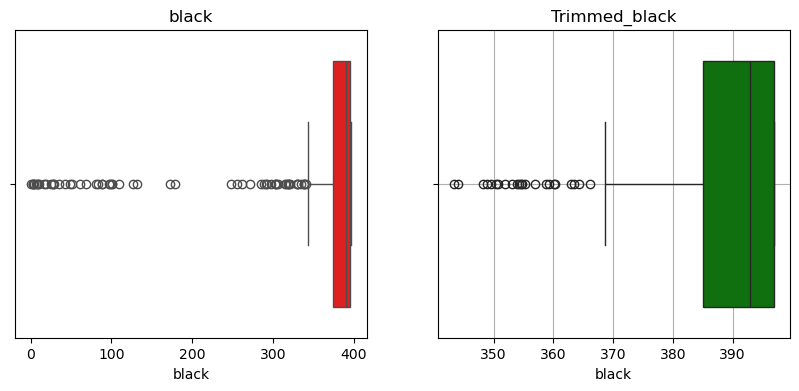

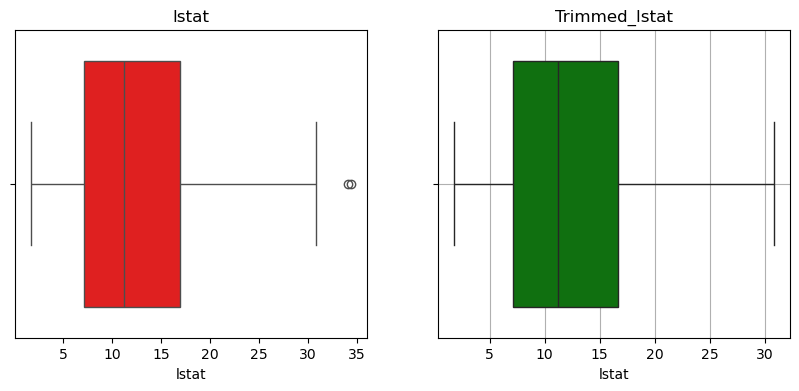

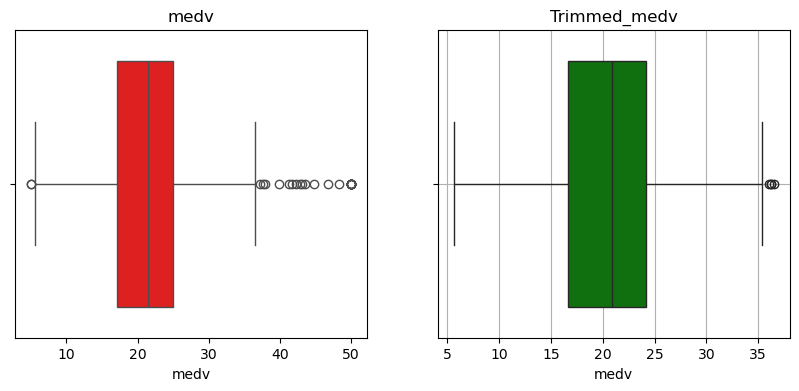

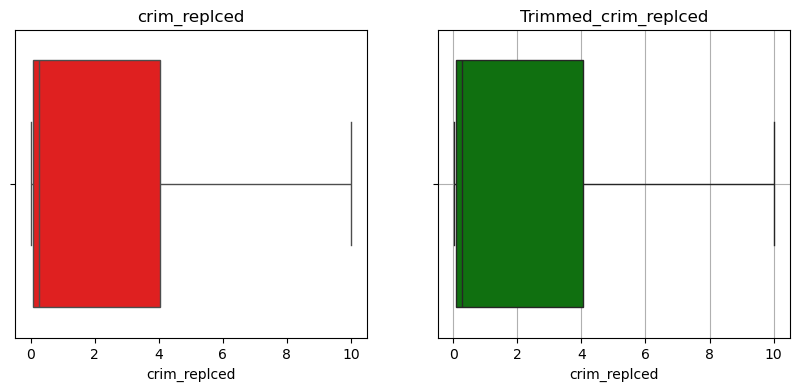

In [42]:
def trimme_Outliers(df):
    for col in df.columns:
        
        # Cleaning
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + IQR * 1.5
        lower_limit = Q1 - IQR * 1.5        
        outliers = ( df[col] > upper_limit ) | ( df[col] < lower_limit )
        trimmed  = df[col].loc[~outliers]
        
        # plotting
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.title(f"{col}")
        sns.boxplot(x = df[col],color='r')
        
        plt.subplot(1,2,2)
        plt.title(f"Trimmed_{col}")
        sns.boxplot(x = trimmed,color='g')
        plt.grid()
        plt.show()

trimme_Outliers(df)

In [26]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [32]:
 # CONCLUSION
 
# in dataframe 9 columns have outliers'
# 1- 'crim'
# 2- 'zn'
# 3- 'chas'
# 4- 'rm'
# 5- 'dis'
# 6- 'black'
# 7- 'ptratio'
# 8- 'lstat'
# 9- 'medv'

In [39]:
df1 = df[['crim','zn','chas','rm','dis','black','ptratio','lstat','medv']]
df1

,crim,zn,chas,rm,dis,black,ptratio,lstat,medv
0,0.15876,0.0,0.0,5.961,5.2873,376.94,19.2,9.88,21.7
1,0.10328,25.0,0.0,5.927,6.9320,396.90,19.7,9.22,19.6
2,0.34940,0.0,0.0,5.972,3.1025,396.24,18.4,9.97,20.3
3,2.73397,0.0,0.0,5.597,1.5257,351.85,14.7,21.45,15.4
4,0.04337,21.0,0.0,6.115,6.8147,393.97,16.8,9.43,20.5
...,...,...,...,...,...,...,...,...,...
399,9.32909,0.0,0.0,6.185,2.2616,396.90,20.2,18.13,14.1
400,51.13580,0.0,0.0,5.757,1.4130,2.60,20.2,10.11,15.0
401,0.01501,90.0,1.0,7.923,5.8850,395.52,13.6,3.16,50.0
402,0.02055,85.0,0.0,6.383,9.1876,396.90,17.3,5.77,24.7


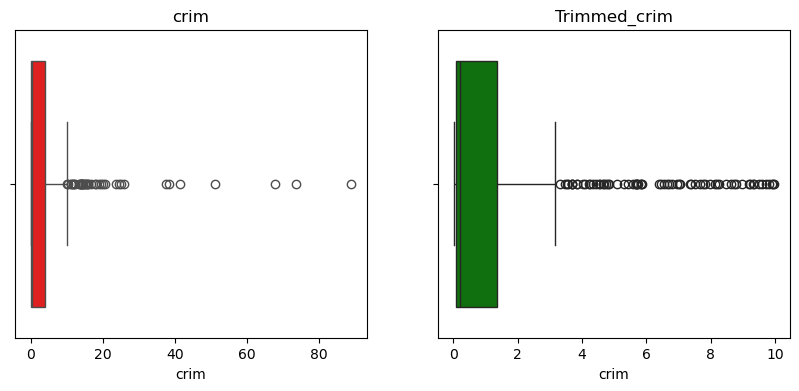

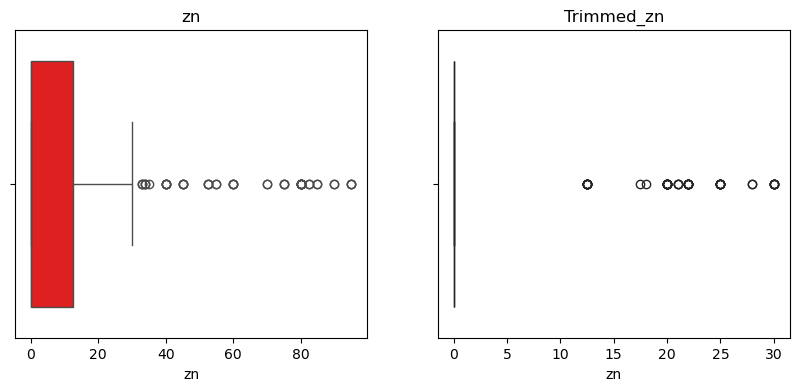

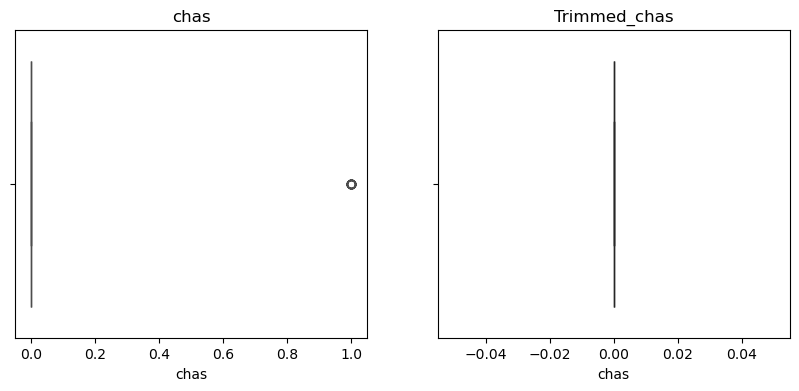

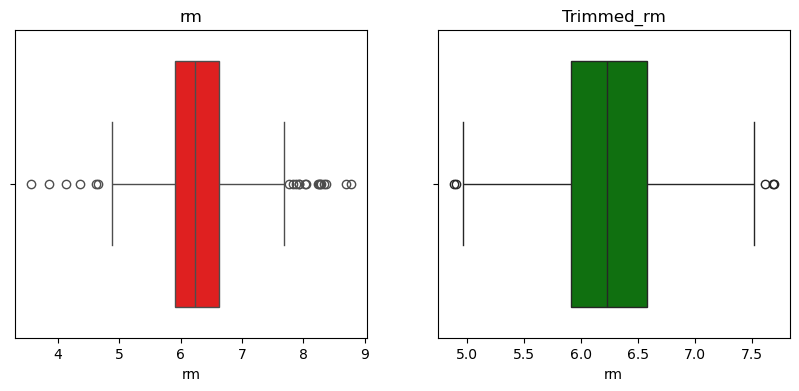

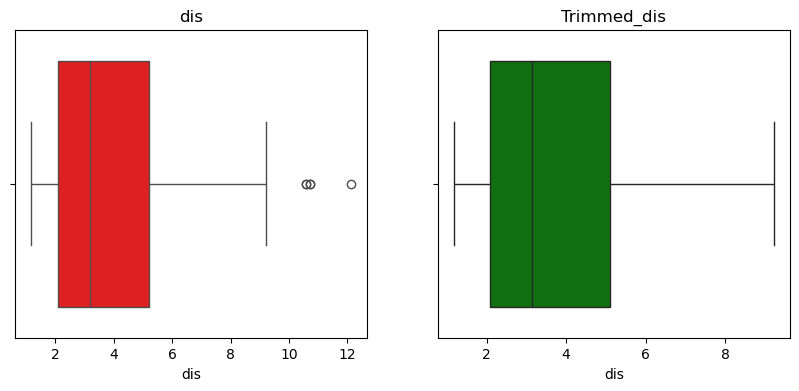

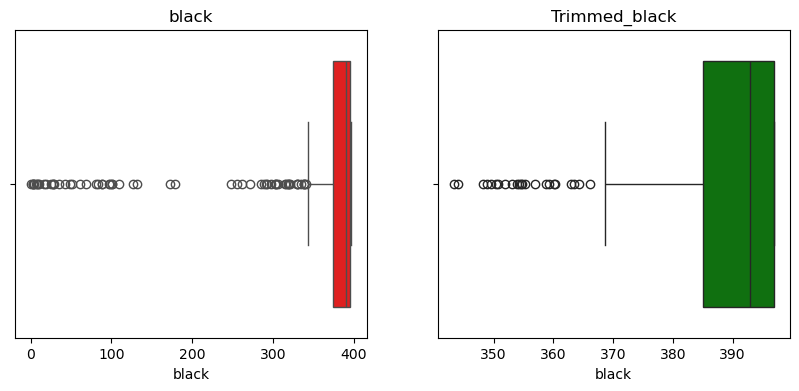

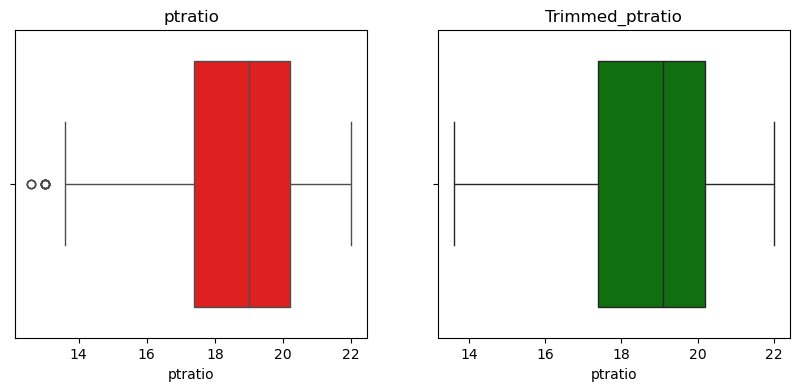

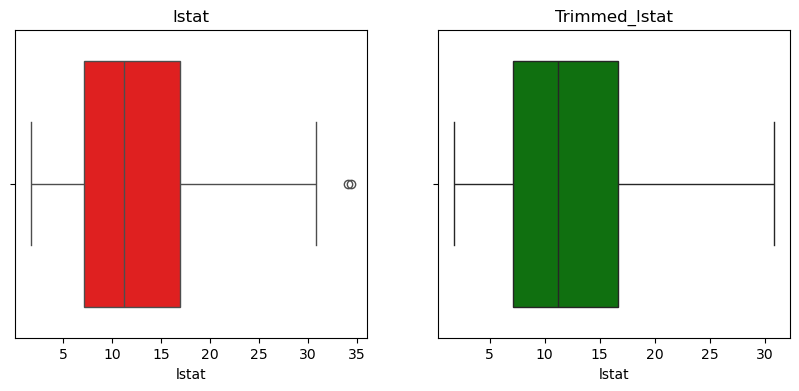

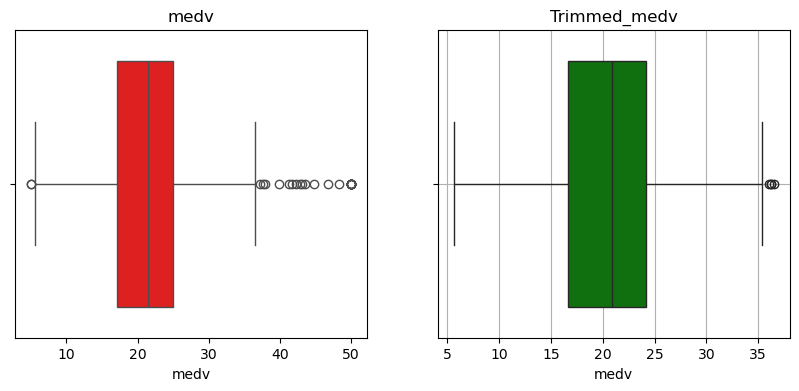

In [41]:
def remove_outliers(df1):
    for col in df1.columns:
        # removing outliers
        
        Q1 = df1[col].quantile(0.25)
        Q3 = df1[col].quantile(0.75)

        IQR = Q3 - Q1

        upper_limit = Q3 + IQR * 1.5
        lower_limit = Q1 - IQR * 1.5
        outliers = (df1[col] > upper_limit) | (df1[col] < lower_limit)
        trimmed_data = df1[col].loc[~outliers]

        # plotting outliers after cleaned

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.title(f"{col}")
        sns.boxplot(x=df1[col],color='r')

        plt.subplot(1,2,2)
        plt.title(f"Trimmed_{col}")
        sns.boxplot(x=trimmed_data,color='g')

    plt.grid()
    plt.show()

remove_outliers(df1)
        

# REPLACE PROCESS

In [ ]:
sns.boxplot(df['crim'],color='r')

In [29]:
IQR  = df['crim'].quantile(0.75) - df['crim'].quantile(0.25)
lower_limit = df['crim'].quantile(0.25) - IQR * 1.5
upper_limit = df['crim'].quantile(0.75) + IQR * 1.5

# replace process

df['crim_replced'] = pd.DataFrame(
    np.where(
        df['crim'] > upper_limit,upper_limit
    ,
    np.where(
        df['crim'] < lower_limit,lower_limit,df['crim']
    )
    )
)

# df["b_replaced"] = pd.DataFrame(np.where(b["crim"] > upper_limit,upper_limit,np.where(b["crim"] < lower_limit,lower_limit,b["crim"])))
# plt.boxplot(b.b_replaced)



<Axes: ylabel='crim_replced'>

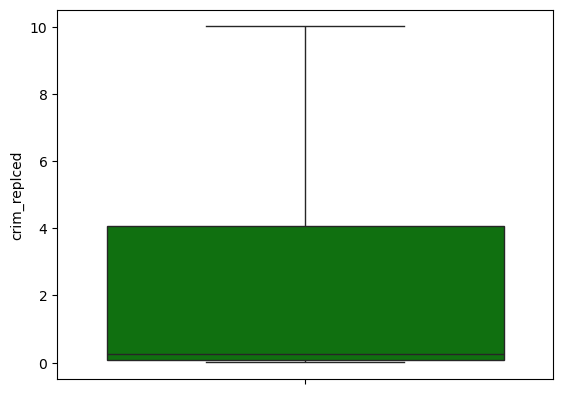

In [30]:
sns.boxplot(df['crim_replced'],color='g')

In [31]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,crim_replced
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,21.7,0.15876
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,19.6,0.10328
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,20.3,0.34940
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,15.4,2.73397
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,20.5,0.04337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,9.32909,0.0,18.10,0.0,0.713,6.185,98.7,2.2616,24.0,666.0,20.2,396.90,18.13,14.1,9.32909
400,51.13580,0.0,18.10,0.0,0.597,5.757,100.0,1.4130,24.0,666.0,20.2,2.60,10.11,15.0,10.00932
401,0.01501,90.0,1.21,1.0,0.401,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,50.0,0.01501
402,0.02055,85.0,0.74,0.0,0.410,6.383,35.7,9.1876,2.0,313.0,17.3,396.90,5.77,24.7,0.02055


# Winsorizer

In [ ]:
sns.boxplot(df['zn'],color='r')

In [43]:
pip install feature_engine

Note: you may need to restart the kernel to use updated packages.


In [45]:
from feature_engine.outliers import Winsorizer

In [46]:
data_1 = Winsorizer(
    capping_method = 'iqr',
    tail='right',
    fold= 1.5,
    variables = ['zn']
)

df['zn_winz'] = data_1.fit_transform(df[['zn']])

<Axes: ylabel='zn_winz'>

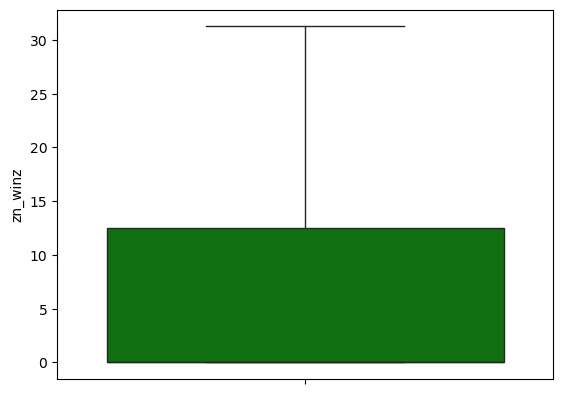

In [47]:
sns.boxplot(df['zn_winz'],color='g')

In [49]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,crim_replced,zn_winz
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.00000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.730912,10.509901,11.189901,0.069307,0.556710,6.30145,68.601733,3.799666,9.836634,411.688119,18.444554,355.068243,12.598936,22.312376,2.411491,6.655322
std,8.943922,22.053733,6.814909,0.254290,0.117321,0.67583,28.066143,2.109916,8.834741,171.073553,2.150295,94.489572,6.925173,8.837019,3.582254,11.766632
min,0.006320,0.000000,0.460000,0.000000,0.392000,3.56100,2.900000,1.169100,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000,0.006320,0.000000
25%,0.082382,0.000000,5.190000,0.000000,0.453000,5.90275,45.800000,2.087875,4.000000,281.000000,17.375000,374.710000,7.135000,17.100000,0.082382,0.000000
50%,0.253715,0.000000,9.795000,0.000000,0.538000,6.23050,76.600000,3.207450,5.000000,330.000000,19.000000,391.065000,11.265000,21.400000,0.253715,0.000000
75%,4.053158,12.500000,18.100000,0.000000,0.631000,6.62925,94.150000,5.222125,24.000000,666.000000,20.200000,396.007500,16.910000,25.000000,4.053158,12.500000
max,88.976200,95.000000,27.740000,1.000000,0.871000,8.78000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,34.370000,50.000000,10.009320,31.250000


In [50]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,crim_replced,zn_winz
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,21.7,0.15876,0.00
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,19.6,0.10328,25.00
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,20.3,0.34940,0.00
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,15.4,2.73397,0.00
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,20.5,0.04337,21.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,9.32909,0.0,18.10,0.0,0.713,6.185,98.7,2.2616,24.0,666.0,20.2,396.90,18.13,14.1,9.32909,0.00
400,51.13580,0.0,18.10,0.0,0.597,5.757,100.0,1.4130,24.0,666.0,20.2,2.60,10.11,15.0,10.00932,0.00
401,0.01501,90.0,1.21,1.0,0.401,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,50.0,0.01501,31.25
402,0.02055,85.0,0.74,0.0,0.410,6.383,35.7,9.1876,2.0,313.0,17.3,396.90,5.77,24.7,0.02055,31.25


In [51]:
df.isna().sum()

crim            0
zn              0
indus           0
chas            0
nox             0
rm              0
age             0
dis             0
rad             0
tax             0
ptratio         0
black           0
lstat           0
medv            0
crim_replced    0
zn_winz         0
dtype: int64

# Handlling Missing Value

In [ ]:
# Drop completely 
# df.drpna(inplace=True)

In [ ]:
# Drop a column
# df_new = df.drop('column_name', axis=1)
# # or
# df_new = df.drop(columns=['column_name'])
